<a href="https://colab.research.google.com/github/vinay22573/AP_Project/blob/master/ShreeGanesh_TataSteel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
BASE_PATH = "/content/drive/MyDrive/Tata_Steel_ML_Challenge/TataSteel_Hackathon/dataset"

train_path = f"{BASE_PATH}/train.csv"
test_path = f"{BASE_PATH}/test.csv"
sample_path = f"{BASE_PATH}/sample_submission.csv"


In [ ]:
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_df = pd.read_csv(sample_path)

print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

train_df.head()

Train Shape : (1352, 51)
Test Shape  : (339, 50)


,CoilID,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X41,X42,X43,X44,X45,X46,X47,X48,X49,Y
0,487,854.787195,501.088868,414.841484,710.583316,662.072013,656.076977,547.040479,563.653582,495.296785,...,0.201645,0.047960,0.267467,0.052247,-0.893174,0.000000,0.028925,0.000534,0.010797,0.0
1,44,1056.526699,868.083321,622.879982,725.276469,665.235554,647.450550,552.333202,565.105074,493.310075,...,0.644403,0.000000,0.341870,0.153513,25.471899,0.002520,0.033281,0.028349,0.079602,0.0
2,192,1095.648362,668.112517,695.787904,716.773671,662.843475,657.542380,549.863867,546.210823,482.814753,...,0.486502,0.000000,0.202539,0.168192,-25.764196,0.002072,0.033878,0.000000,0.058266,0.0
3,1552,1050.943543,660.340015,440.280245,611.562496,628.081103,561.397721,456.816210,550.103433,378.353283,...,1.198010,0.020787,0.288786,0.329108,1.033840,0.000250,0.045490,0.039004,0.004850,0.0
4,1190,1091.640314,297.363775,842.665620,749.160886,652.992309,615.576656,608.364764,549.756758,487.753140,...,0.237231,0.000841,0.257281,0.112637,-11.130157,0.002376,0.031298,0.003623,0.018434,0.0


In [ ]:
X = train_df.drop(columns=["CoilID", "Y"])
y = train_df["Y"]

X_test_final = test_df.drop(columns=["CoilID"])

print("Feature Shape :", X.shape)
print("Target Shape  :", y.shape)

Feature Shape : (1352, 49)
Target Shape  : (1352,)


In [ ]:

train_df.isnull().sum()

,0
CoilID,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0
X7,0
X8,1
X9,0


In [ ]:
missing_percent = train_df.isnull().sum() * 100 / len(train_df)
missing_percent.sort_values(ascending=False)

,0
X15,11.834320
X42,2.292899
X48,0.961538
X26,0.517751
X25,0.443787
X24,0.443787
X27,0.443787
X10,0.443787
X23,0.443787
X16,0.443787


In [ ]:
train_df["X15"].describe()

,X15
count,1192.000000
mean,3.458254
std,2.207777
min,1.173575
25%,2.045622
50%,2.744403
75%,4.072209
max,12.327319


<Axes: >

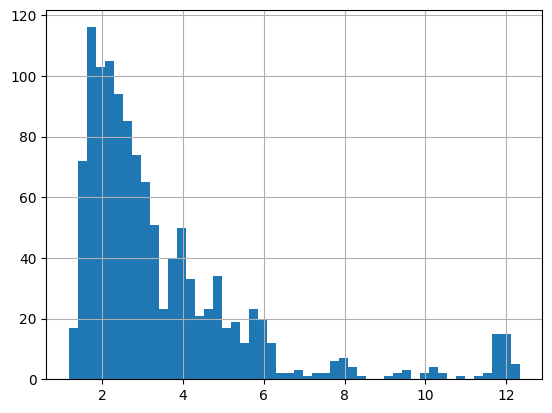

In [ ]:
train_df["X15"].hist(bins=50)

In [ ]:
train_df.groupby(train_df["X15"].isnull())["Y"].mean()

,Y
X15,
False,0.04698
True,0.06250


In [ ]:
# ============================================
# PREPROCESSING
# ============================================

# Separate features and target

X = train_df.drop(columns=["CoilID", "Y"]).copy()
y = train_df["Y"].copy()

X_test_final = test_df.drop(columns=["CoilID"]).copy()

# --------------------------------------------
# Missing indicator for X15
# --------------------------------------------

X["X15_missing"] = X["X15"].isnull().astype(int)
X_test_final["X15_missing"] = X_test_final["X15"].isnull().astype(int)

# --------------------------------------------
# Median imputation
# --------------------------------------------

median_x15 = X["X15"].median()

X["X15"] = X["X15"].fillna(median_x15)
X_test_final["X15"] = X_test_final["X15"].fillna(median_x15)

# --------------------------------------------
# Fill remaining missing values
# --------------------------------------------

X = X.fillna(X.median())
X_test_final = X_test_final.fillna(X_test_final.median())

print("Final X shape:", X.shape)
print("Final Test shape:", X_test_final.shape)


Final X shape: (1352, 50)
Final Test shape: (339, 50)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_valid.shape)

(1081, 50)
(271, 50)


In [ ]:
!pip install lazypredict -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 2.8 MB/s eta 0:00:00


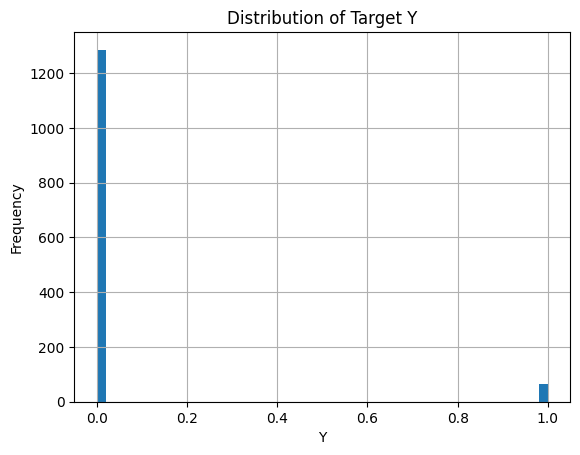

In [ ]:
import matplotlib.pyplot as plt

train_df["Y"].hist(bins=50)

plt.xlabel("Y")
plt.ylabel("Frequency")
plt.title("Distribution of Target Y")

plt.show()

In [ ]:
# from lazypredict.Supervised import LazyClassifier

# clf = LazyClassifier(
#     verbose=0,
#     ignore_warnings=True
# )

# models, predictions = clf.fit(
#     X_train,
#     X_valid,
#     y_train,
#     y_valid
# )

# models

In [ ]:
# sorted_models = models.sort_values(
#     by=["Recall", "Precision", "ROC AUC", "F1 Score"],
#     ascending=False
# )

# sorted_models.head(20)

Explained Variance by PC1: 0.31895761349975515
Explained Variance by PC2: 0.09228821990867284

Total Variance Captured: 0.411245833408428


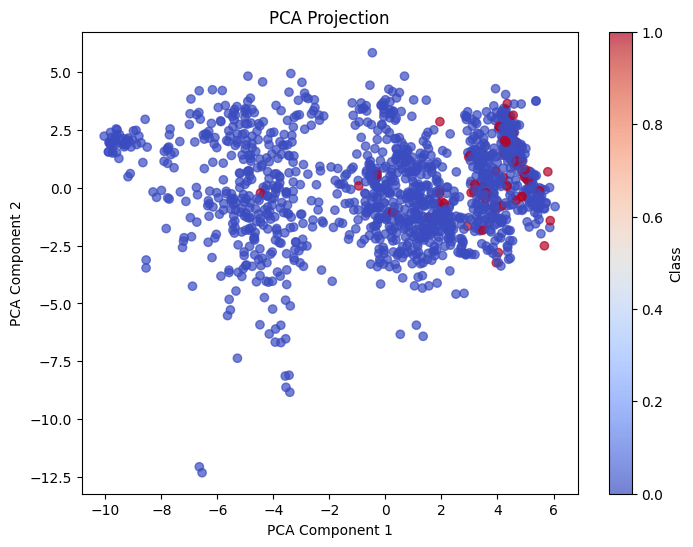

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# =========================
# STEP 1 : SCALE FEATURES
# =========================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# =========================
# STEP 2 : PCA (2 Components)
# =========================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# =========================
# STEP 3 : EXPLAINED VARIANCE
# =========================

explained_variance = pca.explained_variance_ratio_

print("Explained Variance by PC1:", explained_variance[0])
print("Explained Variance by PC2:", explained_variance[1])

print("\nTotal Variance Captured:",
      explained_variance.sum())

# =========================
# STEP 4 : PCA SCATTER PLOT
# =========================

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.colorbar(scatter, label='Class')

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.title("PCA Projection")

plt.show()

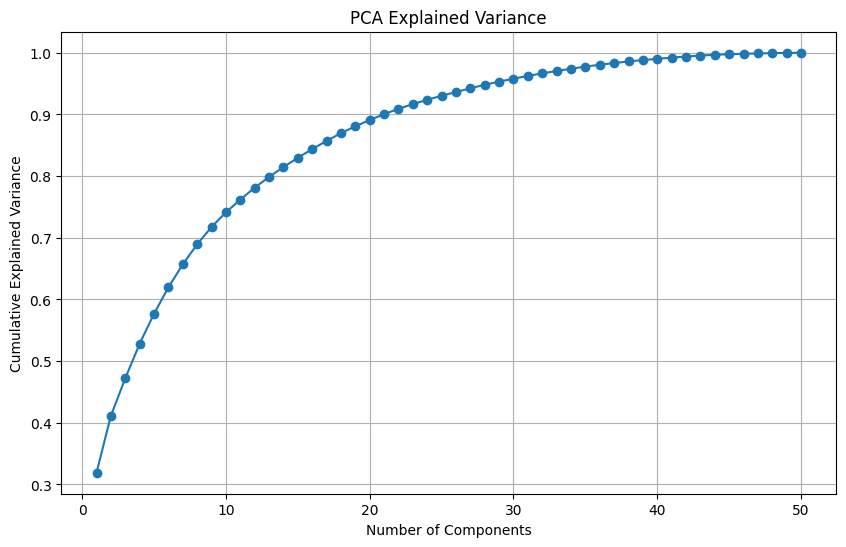

In [ ]:
# =========================
# FULL PCA FOR ALL COMPONENTS
# =========================

pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# =========================
# SCREE PLOT
# =========================

plt.figure(figsize=(10,6))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [ ]:
!pip install umap-learn -q

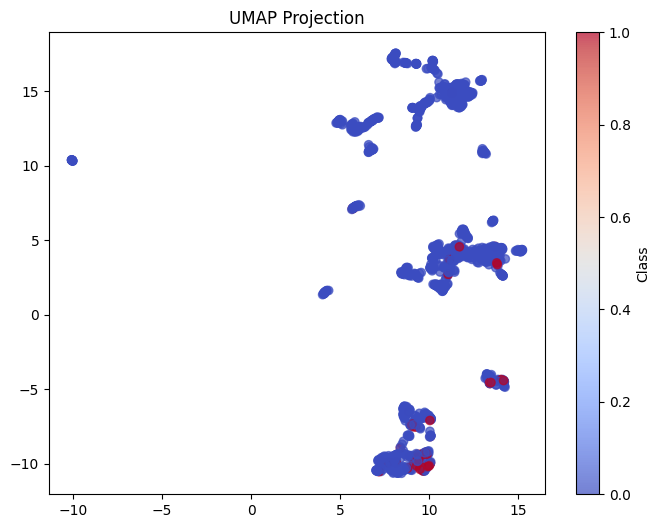

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=y,
    cmap='coolwarm',
    alpha=0.7
)

plt.colorbar(scatter, label='Class')

plt.title("UMAP Projection")

plt.show()

In [ ]:
# # ============================================================
# # ROBUST MODEL VALIDATION USING STRATIFIED K-FOLD CV
# # ============================================================

# # GOAL:
# # -----
# # Instead of trusting a single train-validation split,
# # we evaluate models using Stratified K-Fold Cross Validation
# # to get stable and reliable metrics on imbalanced data.
# #
# # We specifically care about:
# #
# # 1. Recall           -> Must be HIGH (minimize false negatives)
# # 2. Precision        -> Must also stay high
# # 3. Balanced Accuracy
# # 4. ROC AUC
# # 5. F1 Score
# #
# # FINAL FILTER CONDITIONS:
# #
# # Recall            > 0.90
# # Precision         > 0.85
# # Balanced Accuracy > 0.50
# # ROC AUC           > 0.75
# #
# # IMPORTANT:
# # ----------
# # If ROC AUC becomes NaN for some models
# # BUT all remaining conditions are satisfied,
# # we still keep the model.
# #
# # WHY STRATIFIED K-FOLD?
# # ----------------------
# # Because dataset is imbalanced.
# # Each fold preserves class distribution.
# #
# # ============================================================


# # ============================================================
# # IMPORTS
# # ============================================================

# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd

# from sklearn.model_selection import StratifiedKFold
# from lazypredict.Supervised import LazyClassifier


# # ============================================================
# # STRATIFIED K-FOLD SETUP
# # ============================================================

# # 5-fold CV:
# #
# # Data split into 5 parts.
# #
# # Each iteration:
# #   4 folds -> training
# #   1 fold  -> validation
# #
# # Final metrics are averaged across all folds.

# skf = StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
# )


# # ============================================================
# # STORE RESULTS FROM EACH FOLD
# # ============================================================

# all_fold_results = []


# # ============================================================
# # CROSS VALIDATION LOOP
# # ============================================================

# fold_number = 1

# for train_index, valid_index in skf.split(X, y):

#     print(f"\n================ FOLD {fold_number} ================\n")

#     # --------------------------------------------------------
#     # CREATE TRAIN / VALID SPLITS
#     # --------------------------------------------------------

#     X_train_fold = X.iloc[train_index]
#     X_valid_fold = X.iloc[valid_index]

#     y_train_fold = y.iloc[train_index]
#     y_valid_fold = y.iloc[valid_index]


#     # --------------------------------------------------------
#     # RUN LAZYPREDICT
#     # --------------------------------------------------------

#     clf = LazyClassifier(
#         verbose=0,
#         ignore_warnings=True
#     )

#     models, predictions = clf.fit(
#         X_train_fold,
#         X_valid_fold,
#         y_train_fold,
#         y_valid_fold
#     )


#     # --------------------------------------------------------
#     # ADD MODEL NAME AS COLUMN
#     # --------------------------------------------------------

#     models = models.reset_index()
#     models.rename(columns={"Model": "ModelName"}, inplace=True)


#     # --------------------------------------------------------
#     # ADD CURRENT FOLD NUMBER
#     # --------------------------------------------------------

#     models["Fold"] = fold_number


#     # --------------------------------------------------------
#     # STORE RESULTS
#     # --------------------------------------------------------

#     all_fold_results.append(models)

#     fold_number += 1


# # ============================================================
# # COMBINE RESULTS FROM ALL FOLDS
# # ============================================================

# cv_results = pd.concat(
#     all_fold_results,
#     ignore_index=True
# )


# # ============================================================
# # AVERAGE METRICS ACROSS FOLDS
# # ============================================================

# average_results = cv_results.groupby("ModelName").agg({

#     "Accuracy": "mean",
#     "Balanced Accuracy": "mean",
#     "ROC AUC": "mean",
#     "F1 Score": "mean",
#     "Precision": "mean",
#     "Recall": "mean",
#     "Time Taken": "mean"

# }).reset_index()


# # ============================================================
# # SORT MODELS
# # ============================================================

# # Priority:
# #
# # 1. Recall
# # 2. Precision
# # 3. Balanced Accuracy
# # 4. ROC AUC
# # 5. F1 Score

# average_results = average_results.sort_values(

#     by=[
#         "Recall",
#         "Precision",
#         "Balanced Accuracy",
#         "ROC AUC",
#         "F1 Score"
#     ],

#     ascending=False

# )




================ FOLD 1 ================


================ FOLD 2 ================


================ FOLD 3 ================


================ FOLD 4 ================


================ FOLD 5 ================


================ FOLD 6 ================


================ FOLD 7 ================


================ FOLD 8 ================


================ FOLD 9 ================


================ FOLD 10 ================



In [ ]:

# # ============================================================
# # APPLY FILTER CONDITIONS
# # ============================================================

# # CONDITIONS:
# #
# # Recall            > 0.85
# # Precision         > 0.85
# # Balanced Accuracy > 0.50
# #
# # AND:
# #
# # ROC AUC > 0.75
# # OR ROC AUC is NaN

# filtered_models = average_results[

#     (average_results["Recall"] > 0.90) &

#     (average_results["Precision"] > 0.85) &

#     (average_results["Balanced Accuracy"] > 0.50) &

#     (

#         (average_results["ROC AUC"] > 0.75)

#         |

#         (average_results["ROC AUC"].isna())

#     )

# ]




# pd.set_option("display.max_columns", None)

# print("\n===================================================")
# print("ALL MODELS (AVERAGED ACROSS FOLDS)")
# print("===================================================\n")

# display(average_results.head(25))


# print("\n===================================================")
# print("FILTERED HIGH-QUALITY MODELS")
# print("===================================================\n")

# display(filtered_models)


ALL MODELS (AVERAGED ACROSS FOLDS)



,ModelName,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
10,LGBMClassifier,0.953410,0.564341,0.861181,0.938349,0.934771,0.953410,0.718722
7,ExtraTreesClassifier,0.953410,0.544072,0.858631,0.935291,0.927018,0.953410,0.476249
14,LinearSVC,0.953404,0.581417,0.852990,0.940139,0.938990,0.953404,0.094485
20,RandomForestClassifier,0.951193,0.513511,0.855715,0.929952,0.916414,0.951193,1.215355
3,CalibratedClassifierCV,0.951187,0.507943,0.853565,0.928648,0.909859,0.951187,0.368568
22,RidgeClassifierCV,0.951187,0.500000,0.863435,0.927395,0.904770,0.951187,0.133534
21,RidgeClassifier,0.951187,0.500000,0.863094,0.927395,0.904770,0.951187,0.082863
24,SVC,0.951187,0.500000,0.811705,0.927395,0.904770,0.951187,0.098993
5,DummyClassifier,0.951187,0.500000,0.500000,0.927395,0.904770,0.951187,0.071604
9,KNeighborsClassifier,0.950447,0.586613,0.745053,0.938645,0.934512,0.950447,0.084508



FILTERED HIGH-QUALITY MODELS



,ModelName,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
10,LGBMClassifier,0.953410,0.564341,0.861181,0.938349,0.934771,0.953410,0.718722
7,ExtraTreesClassifier,0.953410,0.544072,0.858631,0.935291,0.927018,0.953410,0.476249
14,LinearSVC,0.953404,0.581417,0.852990,0.940139,0.938990,0.953404,0.094485
20,RandomForestClassifier,0.951193,0.513511,0.855715,0.929952,0.916414,0.951193,1.215355
3,CalibratedClassifierCV,0.951187,0.507943,0.853565,0.928648,0.909859,0.951187,0.368568
19,QuadraticDiscriminantAnalysis,0.950447,0.506368,0.792224,0.928300,0.910563,0.950447,0.182455
15,LogisticRegression,0.950441,0.570724,0.864402,0.937893,0.937182,0.950441,0.136109
1,BaggingClassifier,0.948949,0.532604,0.773070,0.931453,0.917354,0.948949,0.882153
0,AdaBoostClassifier,0.948208,0.573936,0.852176,0.937288,0.935182,0.948208,1.247924
11,LabelPropagation,0.945272,0.688782,NaN,0.944183,0.945623,0.945272,0.297816


In [ ]:
# final_model_names = [

#     "ExtraTreesClassifier",
#     "RandomForestClassifier",

#     "LGBMClassifier",
#     "XGBClassifier",
#     "AdaBoostClassifier",

#     "LogisticRegression",
#     "LinearSVC",

#     "LinearDiscriminantAnalysis",
#     "QuadraticDiscriminantAnalysis",

#     "LabelPropagation",
#     "LabelSpreading"
# ]

# final_models = filtered_models[
#     filtered_models["ModelName"].isin(final_model_names)
# ]

# final_models = final_models.sort_values(

#     by=[
#         "Recall",
#         "Precision",
#         "Balanced Accuracy",
#         "ROC AUC",
#         "F1 Score"
#     ],

#     ascending=False

# )

# pd.set_option("display.max_columns", None)

# final_models

,ModelName,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
10,LGBMClassifier,0.953410,0.564341,0.861181,0.938349,0.934771,0.953410,0.718722
7,ExtraTreesClassifier,0.953410,0.544072,0.858631,0.935291,0.927018,0.953410,0.476249
14,LinearSVC,0.953404,0.581417,0.852990,0.940139,0.938990,0.953404,0.094485
20,RandomForestClassifier,0.951193,0.513511,0.855715,0.929952,0.916414,0.951193,1.215355
19,QuadraticDiscriminantAnalysis,0.950447,0.506368,0.792224,0.928300,0.910563,0.950447,0.182455
15,LogisticRegression,0.950441,0.570724,0.864402,0.937893,0.937182,0.950441,0.136109
0,AdaBoostClassifier,0.948208,0.573936,0.852176,0.937288,0.935182,0.948208,1.247924
11,LabelPropagation,0.945272,0.688782,NaN,0.944183,0.945623,0.945272,0.297816
12,LabelSpreading,0.945272,0.688782,NaN,0.944183,0.945623,0.945272,0.358499
25,XGBClassifier,0.944526,0.543780,0.843403,0.931264,0.923134,0.944526,0.819410


In [ ]:


# from lightgbm import LGBMClassifier

# from sklearn.model_selection import (
#     RandomizedSearchCV,
#     StratifiedKFold
# )

# from sklearn.metrics import (
#     classification_report,
#     confusion_matrix
# )

# import numpy as np




# lgbm = LGBMClassifier(
#     objective='binary',
#     class_weight='balanced',
#     random_state=42
# )





# param_grid = {




#     "n_estimators": [
#         300,
#         500,
#         800,
#         1200,
#         1500
#     ],



#     "learning_rate": [
#         0.03,
#         0.05,
#         0.07,
#         0.1,
#         0.15
#     ],


#     "max_depth": [
#         5,
#         7,
#         10,
#         15,
#         -1
#     ],



#     "num_leaves": [
#         31,
#         63,
#         127,
#         255,
#         511
#     ],


#     "min_child_samples": [
#         3,
#         5,
#         10,
#         20,
#         30
#     ],

#     "subsample": [
#         0.7,
#         0.8,
#         0.9,
#         1.0
#     ],

#     "colsample_bytree": [
#         0.6,
#         0.7,
#         0.8,
#         0.9,
#         1.0
#     ]

# }


# # ============================================================
# # STRATIFIED K-FOLD
# # ============================================================

# skf = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )


# # ============================================================
# # RANDOM SEARCH
# # ============================================================

# search = RandomizedSearchCV(

#     estimator=lgbm,

#     param_distributions=param_grid,

#     n_iter=40,   # number of random combinations

#     scoring='recall',   # VERY IMPORTANT

#     cv=skf,

#     verbose=2,

#     random_state=42,

#     n_jobs=-1
# )


# # ============================================================
# # TRAIN SEARCH
# # ============================================================

# search.fit(X, y)


# # ============================================================
# # BEST MODEL
# # ============================================================

# best_lgbm = search.best_estimator_

# print("\n================ BEST PARAMETERS ================\n")

# print(search.best_params_)


# print("\n================ BEST CV RECALL ================\n")

# print(search.best_score_)

In [ ]:


# import time
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd

# from tqdm.notebook import tqdm

# from sklearn.neighbors import KNeighborsClassifier

# from sklearn.preprocessing import StandardScaler

# from sklearn.model_selection import (
#     StratifiedKFold,
#     ParameterGrid,
#     cross_validate
# )



# scaler = StandardScaler()

# X_scaled = scaler.fit_transform(X)



# skf = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )


# # ============================================================
# # HYPERPARAMETER SEARCH SPACE
# # ============================================================

# param_grid = {

#     # --------------------------------------------------------
#     # Number of neighbors
#     # --------------------------------------------------------
#     #
#     # Small k:
#     # more local/sensitive
#     #
#     # Large k:
#     # smoother/generalized
#     #
#     "n_neighbors": [
#         3,
#         5,
#         7,
#         11,
#         15
#     ],


#     # --------------------------------------------------------
#     # Weighting strategy
#     # --------------------------------------------------------
#     #
#     # uniform:
#     # all neighbors equal
#     #
#     # distance:
#     # closer neighbors matter more
#     #
#     "weights": [
#         "uniform",
#         "distance"
#     ],


#     # --------------------------------------------------------
#     # Distance metric
#     # --------------------------------------------------------
#     #
#     # euclidean:
#     # standard geometric distance
#     #
#     # manhattan:
#     # grid/block distance
#     #
#     # minkowski:
#     # generalized metric
#     #
#     "metric": [
#         "euclidean",
#         "manhattan",
#         "minkowski"
#     ],


#     # --------------------------------------------------------
#     # Power parameter for minkowski
#     # --------------------------------------------------------
#     #
#     # p=1 -> Manhattan
#     # p=2 -> Euclidean
#     #
#     "p": [
#         1,
#         2
#     ]
# }


# # ============================================================
# # GENERATE ALL COMBINATIONS
# # ============================================================

# all_params = list(ParameterGrid(param_grid))

# print(f"\nTotal Configurations: {len(all_params)}\n")


# # ============================================================
# # RESULTS STORAGE
# # ============================================================

# results = []


# # ============================================================
# # SEARCH LOOP
# # ============================================================

# start_total = time.time()

# for i, params in enumerate(
#     tqdm(all_params, desc="KNN Hyperparameter Search")
# ):

#     start_iter = time.time()

#     # --------------------------------------------------------
#     # MODEL
#     # --------------------------------------------------------

#     model = KNeighborsClassifier(
#         **params
#     )


#     # --------------------------------------------------------
#     # CROSS VALIDATION
#     # --------------------------------------------------------

#     scores = cross_validate(

#         estimator=model,

#         X=X_scaled,

#         y=y,

#         cv=skf,

#         scoring={

#             "recall": "recall",

#             "precision": "precision",

#             "balanced_accuracy": "balanced_accuracy",

#             "roc_auc": "roc_auc",

#             "f1": "f1"

#         },

#         n_jobs=-1

#     )


#     # --------------------------------------------------------
#     # STORE AVERAGE SCORES
#     # --------------------------------------------------------

#     results.append({

#         "n_neighbors":
#             params["n_neighbors"],

#         "weights":
#             params["weights"],

#         "metric":
#             params["metric"],

#         "p":
#             params["p"],


#         "Recall":
#             np.mean(scores["test_recall"]),

#         "Precision":
#             np.mean(scores["test_precision"]),

#         "Balanced Accuracy":
#             np.mean(scores["test_balanced_accuracy"]),

#         "ROC AUC":
#             np.mean(scores["test_roc_auc"]),

#         "F1 Score":
#             np.mean(scores["test_f1"]),


#         "Time Taken (s)":
#             time.time() - start_iter

#     })


# # ============================================================
# # TOTAL SEARCH TIME
# # ============================================================

# end_total = time.time()

# print(
#     f"\nTotal Search Time: "
#     f"{(end_total - start_total)/60:.2f} minutes"
# )


# # ============================================================
# # RESULTS DATAFRAME
# # ============================================================

# knn_results = pd.DataFrame(results)


# # ============================================================
# # SORT RESULTS
# # ============================================================

# knn_results = knn_results.sort_values(

#     by=[
#         "Recall",
#         "Precision",
#         "Balanced Accuracy",
#         "ROC AUC",
#         "F1 Score"
#     ],

#     ascending=False

# )


# # ============================================================
# # DISPLAY TOP RESULTS
# # ============================================================

# pd.set_option("display.max_columns", None)

# print("\n===================================================")
# print("TOP KNN CONFIGURATIONS")
# print("===================================================\n")

# display(
#     knn_results.head(20)
# )

In [ ]:
# print(train_df["Y"].value_counts())
# print(train_df["Y"].value_counts(normalize=True))

Y
0.0    1286
1.0      66
Name: count, dtype: int64
Y
0.0    0.951183
1.0    0.048817
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# SECTION 3 — REUSABLE UTILITIES
# ============================================================

# PURPOSE
# -------
# This section contains reusable ML experimentation utilities:
#
# 1. Cross Validation Runner
# 2. Resampling + LazyPredict Pipeline
# 3. Filtering Utilities
# 4. Sorting Utilities
# 5. Visualization Utilities
# 6. Timing + tqdm UX
#
# These utilities will later help compare:
#
# - SMOTE
# - BorderlineSMOTE
# - ADASYN
# - KMeansSMOTE
#
# on exactly the same evaluation framework.
#


import time
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from lazypredict.Supervised import LazyClassifier
pd.set_option("display.max_columns", None)


def sort_models(df):
    return df.sort_values(
        by=[
            "Recall",
            "Precision",
            "Balanced Accuracy",
            "ROC AUC",
            "F1 Score"
        ],

        ascending=False
    )





def run_lazypredict_cv(
    X,
    y,
    resampler=None,
    n_splits=5,
    random_state=42,
    show_details=True
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )
    all_results = []
    total_start = time.time()
    for fold_no, (train_idx, valid_idx) in enumerate(
        tqdm(
            skf.split(X, y),
            total=n_splits,
            desc="CV Progress"
        ),

        start=1
    ):
        fold_start = time.time()
        X_train = X.iloc[train_idx].copy()
        X_valid = X.iloc[valid_idx].copy()
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        # Fold-wise imputation
        imputer = SimpleImputer(strategy="median")
        X_train = pd.DataFrame(
            imputer.fit_transform(X_train),
            columns=X.columns
        )
        X_valid = pd.DataFrame(
            imputer.transform(X_valid),
            columns=X.columns
        )

        # Resampling
        if resampler is not None:
            X_train_resampled, y_train_resampled = (
                resampler.fit_resample(
                    X_train,
                    y_train
                )
            )
        else:
            X_train_resampled = X_train
            y_train_resampled = y_train
        if show_details:
            print(f"\n========== FOLD {fold_no} ==========")
            print("\nBefore Resampling:")
            print(y_train.value_counts())
            print("\nAfter Resampling:")
            print(pd.Series(y_train_resampled).value_counts())

        clf = LazyClassifier(
            verbose=0,
            ignore_warnings=True
        )
        models, predictions = clf.fit(
            X_train_resampled,
            X_valid,
            y_train_resampled,
            y_valid
        )
        models["Fold"] = fold_no
        all_results.append(models)
        fold_end = time.time()
        if show_details:
            print(
                f"\nFold Time: "
                f"{(fold_end - fold_start)/60:.2f} min"
            )
    total_end = time.time()
    print(
        f"\nTOTAL CV TIME: "
        f"{(total_end - total_start)/60:.2f} min"
    )
    final_results = pd.concat(all_results)
    avg_results = (
        final_results
        .groupby(final_results.index)
        .mean(numeric_only=True)
    )
    avg_results = sort_models(avg_results)
    return avg_results



def filter_models(
    df,
    recall=0.90,
    precision=0.85,
    balanced_acc=0.50,
    roc_auc=0.75
):

    return df[

        (df["Recall"] >= recall) &
        (df["Precision"] >= precision) &
        (df["Balanced Accuracy"] >= balanced_acc) &
        (
            (df["ROC AUC"] >= roc_auc) |
            (df["ROC AUC"].isna())
        )
    ]



In [ ]:
# ============================================================
# PLOT
# ============================================================

def plot_metric_distribution(
    results_df,
    metric="Recall",
    top_n=20
):
    """
    Plot metric distribution for top models.
    """
    plot_df = results_df.head(top_n)
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=plot_df,
        x=metric,
        y=plot_df.index
    )
    plt.title(f"Top {top_n} Models by {metric}")
    plt.xlabel(metric)
    plt.ylabel("Model")
    plt.show()


def plot_class_distribution(y_before, y_after):

    """
    Compare class distribution before and after resampling.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
  # BEFORE
    y_before.value_counts().plot(
        kind="bar",
        ax=axes[0]
    )
    axes[0].set_title("Before Resampling")
    # AFTER
    pd.Series(y_after).value_counts().plot(
        kind="bar",
        ax=axes[1]
    )
    axes[1].set_title("After Resampling")
    plt.show()

In [ ]:
# Testing K-Means SMOTE with a very low clustering threshodl vaue
# from imblearn.over_sampling import KMeansSMOTE

# kmeans_smote = KMeansSMOTE(random_state=42,
#                            cluster_balance_threshold=0.001,
#                            k_neighbors=2)

# results = run_lazypredict_cv(
#     X,
#     y,
#     resampler=kmeans_smote
# )



CV Progress:   0%|          | 0/5 [00:00<?, ?it/s]


========== FOLD 1 ==========

Before Resampling:
Y
0.0    1028
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1029
0.0    1028
Name: count, dtype: int64

Fold Time: 0.16 min

========== FOLD 2 ==========

Before Resampling:
Y
0.0    1029
1.0      52
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.23 min

========== FOLD 3 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.45 min

========== FOLD 4 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1032
0.0    1029
Name: count, dtype: int64

Fold Time: 0.50 min

========== FOLD 5 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.30 min

TOTAL CV TIME: 1.64 min


In [ ]:
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

# --------------------------------------------------
# HANDLE NaNs
# --------------------------------------------------

imputer = SimpleImputer(strategy="median")

X_imputed = pd.DataFrame(

    imputer.fit_transform(X),

    columns=X.columns

)

# --------------------------------------------------
# KMeans Clustering
# --------------------------------------------------

n_clusters = 10

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42
)

clusters = kmeans.fit_predict(X_imputed)

# --------------------------------------------------
# CREATE ANALYSIS DF
# --------------------------------------------------

cluster_df = pd.DataFrame({

    "Cluster": clusters,
    "Target": y

})

# --------------------------------------------------
# CLUSTER-WISE DISTRIBUTION
# --------------------------------------------------

summary = (

    cluster_df

    .groupby("Cluster")["Target"]

    .value_counts()

    .unstack(fill_value=0)

)

summary.columns = ["Negative", "Positive"]

summary["Total"] = (

    summary["Negative"] +
    summary["Positive"]

)

summary["Minority_Ratio"] = (

    summary["Positive"] /
    summary["Total"]

)

summary = summary.sort_values(
    by="Minority_Ratio",
    ascending=False
)

display(summary)

,Negative,Positive,Total,Minority_Ratio
Cluster,,,,
5,83,20,103,0.194175
0,240,32,272,0.117647
8,49,5,54,0.092593
4,44,1,45,0.022222
2,73,1,74,0.013514
3,226,3,229,0.013100
7,170,2,172,0.011628
1,229,2,231,0.008658
6,83,0,83,0.000000


In [ ]:
# Testing K-Means SMOTE with a changed Value for better capturing of all positives

from imblearn.over_sampling import KMeansSMOTE

kmeans_smote = KMeansSMOTE(random_state=42,
                           cluster_balance_threshold=0.0085,
                           k_neighbors=2)

results = run_lazypredict_cv(
    X,
    y,
    resampler=kmeans_smote
)




CV Progress:   0%|          | 0/5 [00:00<?, ?it/s]


========== FOLD 1 ==========

Before Resampling:
Y
0.0    1028
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1029
0.0    1028
Name: count, dtype: int64

Fold Time: 0.25 min

========== FOLD 2 ==========

Before Resampling:
Y
0.0    1029
1.0      52
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.26 min

========== FOLD 3 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.21 min

========== FOLD 4 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1032
0.0    1029
Name: count, dtype: int64

Fold Time: 0.22 min

========== FOLD 5 ==========

Before Resampling:
Y
0.0    1029
1.0      53
Name: count, dtype: int64

After Resampling:
Y
1.0    1030
0.0    1029
Name: count, dtype: int64

Fold Time: 0.29 min

TOTAL CV TIME: 1.24 min


In [ ]:
display(results.head(20))

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken,Fold
Model,,,,,,,,
ExtraTreesClassifier,0.951185,0.615204,0.869607,0.942853,0.940443,0.951185,0.630973,3.0
QuadraticDiscriminantAnalysis,0.951185,0.500000,0.558307,0.927389,0.904755,0.951185,0.291788,3.0
LGBMClassifier,0.946005,0.619785,0.853711,0.940321,0.937752,0.946005,1.032044,3.0
BaggingClassifier,0.943786,0.618067,0.767408,0.938570,0.936560,0.943786,2.025866,3.0
XGBClassifier,0.943783,0.632675,0.861139,0.939530,0.936736,0.943783,1.454233,3.0
RandomForestClassifier,0.941572,0.566878,0.841106,0.932409,0.927405,0.941572,3.263787,3.0
LabelSpreading,0.936384,0.723190,NaN,0.939659,0.944121,0.936384,0.782058,3.0
LabelPropagation,0.935643,0.722801,NaN,0.939205,0.943997,0.935643,0.465152,3.0
SVC,0.923078,0.709438,0.856474,0.930355,0.940060,0.923078,0.192472,3.0


In [ ]:
best_models = (

    filter_models(results)

    .sort_values(
        by=[
            "Recall",
            "Precision",
            "ROC AUC",
            "F1 Score",
            "Balanced Accuracy"
        ],
        ascending=False
    )

    [[
        "Recall",
        "Precision",
        "ROC AUC",
        "F1 Score",
        "Balanced Accuracy",
        "Accuracy",
        "Time Taken"
    ]]
)

display(best_models)

,Recall,Precision,ROC AUC,F1 Score,Balanced Accuracy,Accuracy,Time Taken
Model,,,,,,,
ExtraTreesClassifier,0.951185,0.940443,0.869607,0.942853,0.615204,0.951185,0.630973
LGBMClassifier,0.946005,0.937752,0.853711,0.940321,0.619785,0.946005,1.032044
BaggingClassifier,0.943786,0.936560,0.767408,0.938570,0.618067,0.943786,2.025866
XGBClassifier,0.943783,0.936736,0.861139,0.939530,0.632675,0.943783,1.454233
RandomForestClassifier,0.941572,0.927405,0.841106,0.932409,0.566878,0.941572,3.263787
LabelSpreading,0.936384,0.944121,NaN,0.939659,0.723190,0.936384,0.782058
LabelPropagation,0.935643,0.943997,NaN,0.939205,0.722801,0.935643,0.465152
SVC,0.923078,0.940060,0.856474,0.930355,0.709438,0.923078,0.192472
SGDClassifier,0.909761,0.934281,0.849574,0.920576,0.681073,0.909761,0.149992


In [ ]:
# import time
# import warnings
# warnings.filterwarnings("ignore")

# import numpy as np
# import pandas as pd

# from tqdm.auto import tqdm

# from sklearn.model_selection import (
#     StratifiedKFold,
#     RandomizedSearchCV,
#     cross_validate
# )

# from sklearn.metrics import (
#     make_scorer,
#     recall_score,
#     precision_score,
#     f1_score,
#     balanced_accuracy_score
# )

# from sklearn.ensemble import ExtraTreesClassifier

# from imblearn.over_sampling import KMeansSMOTE

# # =========================================================
# # KMEANS SMOTE
# # =========================================================

# print("="*70)
# print("Applying KMeansSMOTE...")
# print("="*70)

# smote = KMeansSMOTE(
#     random_state=42,
#     cluster_balance_threshold=0.005,
#     k_neighbors=2
# )

# X_resampled, y_resampled = smote.fit_resample(X, y)

# print("\nOriginal Distribution:")
# print(y.value_counts())

# print("\nResampled Distribution:")
# print(pd.Series(y_resampled).value_counts())

# # =========================================================
# # MODEL
# # =========================================================

# model = ExtraTreesClassifier(
#     random_state=42,
#     n_jobs=1
# )

# # =========================================================
# # ULTRA LOCAL SEARCH SPACE
# # =========================================================

# param_grid = {

#     "n_estimators": [
#         480,
#         500,
#         520
#     ],

#     "max_depth": [
#         12
#     ],

#     "min_samples_split": [
#         2,
#         3
#     ],

#     "min_samples_leaf": [
#         1,
#         2
#     ],

#     "max_features": [
#         "sqrt",
#         0.7
#     ],

#     "bootstrap": [
#         False
#     ]
# }

# # =========================================================
# # CV
# # =========================================================

# skf = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# # =========================================================
# # SEARCH INFO
# # =========================================================

# total_iters = 20

# print("\n" + "="*70)
# print("Starting Ultra Localized ExtraTrees Search")
# print("="*70)

# print(f"\nIterations   : {total_iters}")
# print(f"CV Folds     : 5")
# print(f"Total Fits   : {total_iters * 5}")

# search_start = time.time()

# # =========================================================
# # RANDOM SEARCH
# # =========================================================

# search = RandomizedSearchCV(

#     estimator=model,

#     param_distributions=param_grid,

#     n_iter=total_iters,

#     scoring="f1",

#     cv=skf,

#     verbose=3,

#     n_jobs=-1,

#     random_state=42,

#     return_train_score=True
# )

# search.fit(X_resampled, y_resampled)

# search_end = time.time()

# # =========================================================
# # SEARCH RESULTS
# # =========================================================

# print("\n" + "="*70)
# print("SEARCH COMPLETED")
# print("="*70)

# print(
#     f"\nTotal Search Time : "
#     f"{(search_end-search_start)/60:.2f} min"
# )

# print("\nBest F1 Score :")
# print(round(search.best_score_, 5))

# print("\nBest Parameters :")
# print(search.best_params_)

# # =========================================================
# # TOP CONFIGS
# # =========================================================

# cv_results = pd.DataFrame(search.cv_results_)

# top_configs = (

#     cv_results

#     .sort_values(
#         by="mean_test_score",
#         ascending=False
#     )

#     .head(5)
# )

# search_results = pd.DataFrame({

#     "F1 Score":
#         top_configs["mean_test_score"].values,

#     "Train Score":
#         top_configs["mean_train_score"].values,

#     "Fit Time":
#         top_configs["mean_fit_time"].values,

#     "Rank":
#         top_configs["rank_test_score"].values,

#     "Params":
#         top_configs["params"].values
# })

# print("\n" + "="*70)
# print("TOP SEARCH CONFIGURATIONS")
# print("="*70)

# display(search_results)

# # =========================================================
# # FINAL VALIDATION ON TOP 2
# # =========================================================

# top_2_params = top_configs["params"].values[:2]

# final_models = {

#     f"ExtraTrees_{i+1}":

#     ExtraTreesClassifier(

#         **params,

#         random_state=42,

#         n_jobs=1

#     )

#     for i, params in enumerate(top_2_params)
# }

# # =========================================================
# # SCORING
# # =========================================================

# scoring = {

#     "recall":
#         make_scorer(recall_score),

#     "precision":
#         make_scorer(precision_score),

#     "f1":
#         make_scorer(f1_score),

#     "balanced_acc":
#         make_scorer(balanced_accuracy_score),

#     "roc_auc":
#         "roc_auc"
# }

# # =========================================================
# # FINAL CV EVALUATION
# # =========================================================

# print("\n" + "="*70)
# print("Running Final 5-Fold Validation")
# print("="*70)

# results = []

# overall_start = time.time()

# for model_name, model in tqdm(
#     final_models.items(),
#     desc="Evaluating Models"
# ):

#     print("\n" + "-"*70)
#     print(f"Training : {model_name}")
#     print("-"*70)

#     start_time = time.time()

#     scores = cross_validate(

#         estimator=model,

#         X=X_resampled,

#         y=y_resampled,

#         cv=skf,

#         scoring=scoring,

#         n_jobs=-1,

#         return_train_score=True
#     )

#     end_time = time.time()

#     results.append({

#         "Model":
#             model_name,

#         "Recall":
#             np.mean(scores["test_recall"]),

#         "Precision":
#             np.mean(scores["test_precision"]),

#         "ROC AUC":
#             np.mean(scores["test_roc_auc"]),

#         "F1 Score":
#             np.mean(scores["test_f1"]),

#         "Balanced Accuracy":
#             np.mean(scores["test_balanced_acc"]),

#         "Train Recall":
#             np.mean(scores["train_recall"]),

#         "Time Taken":
#             round(end_time-start_time, 2)
#     })

#     print(
#         f"\nCompleted in "
#         f"{(end_time-start_time):.2f} sec"
#     )

# overall_end = time.time()

# # =========================================================
# # FINAL RESULTS
# # =========================================================

# results_df = (

#     pd.DataFrame(results)

#     .sort_values(

#         by=[
#             "Recall",
#             "Precision",
#             "ROC AUC",
#             "F1 Score"
#         ],

#         ascending=False
#     )
# )

# print("\n" + "="*70)
# print("FINAL RESULTS")
# print("="*70)

# print(
#     f"\nTotal Validation Time : "
#     f"{(overall_end-overall_start)/60:.2f} min"
# )

# display(results_df)

Applying KMeansSMOTE...

Original Distribution:
Y
0.0    1286
1.0      66
Name: count, dtype: int64

Resampled Distribution:
Y
1.0    1288
0.0    1286
Name: count, dtype: int64

Starting 5-Fold Cross Validation


Training Models:   0%|          | 0/2 [00:00<?, ?it/s]


----------------------------------------------------------------------
Training : ExtraTrees_1
----------------------------------------------------------------------

Completed in 7.17 sec

----------------------------------------------------------------------
Training : ExtraTrees_2
----------------------------------------------------------------------

Completed in 11.26 sec

FINAL RESULTS

Total Experiment Time : 0.31 min


,Model,Recall,Precision,ROC AUC,F1 Score,Balanced Accuracy,Train Recall,Time Taken
0,ExtraTrees_1,0.988354,0.916144,0.994536,0.950791,0.948680,0.989713,7.17
1,ExtraTrees_2,0.985247,0.988387,0.996826,0.986791,0.986787,1.000000,11.26


In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score
)

from sklearn.ensemble import ExtraTreesClassifier

from imblearn.over_sampling import KMeansSMOTE

# =========================================================
# KMEANS SMOTE
# =========================================================

print("="*70)
print("Applying KMeansSMOTE...")
print("="*70)

smote = KMeansSMOTE(
    random_state=42,
    cluster_balance_threshold=0.005,
    k_neighbors=2
)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nOriginal Distribution:")
print(y.value_counts())

print("\nResampled Distribution:")
print(pd.Series(y_resampled).value_counts())

# =========================================================
# MODEL
# =========================================================

model = ExtraTreesClassifier(
    random_state=42,
    n_jobs=1
)

# =========================================================
# LOCAL SEARCH SPACE
# =========================================================

param_grid = {

    "n_estimators": [
        480,
        500,
        520,
    ],

    "max_depth": [
        8,
        10,
        12,
        14
    ],

    "min_samples_split": [
        2,
        3
    ],

    "min_samples_leaf": [
        1,
        2,
        3
    ],

    "max_features": [
        "sqrt",
        0.7,
    ],

    "bootstrap": [
        False
    ]
}

# =========================================================
# CV
# =========================================================

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================================================
# SEARCH INFO
# =========================================================

total_iters = 40

print("\n" + "="*70)
print("Starting Localized ExtraTrees Search")
print("="*70)

print(f"\nIterations   : {total_iters}")
print(f"CV Folds     : 5")
print(f"Total Fits   : {total_iters * 5}")

search_start = time.time()

# =========================================================
# RANDOM SEARCH
# =========================================================

search = RandomizedSearchCV(

    estimator=model,

    param_distributions=param_grid,

    n_iter=total_iters,

    scoring={
        "recall": "recall",
        "precision": "precision",
        "f1": "f1"
    },

    refit="recall",

    cv=skf,

    verbose=3,

    n_jobs=-1,

    random_state=42,

    return_train_score=True
)

search.fit(X_resampled, y_resampled)

search_end = time.time()

# =========================================================
# SEARCH RESULTS
# =========================================================

print("\n" + "="*70)
print("SEARCH COMPLETED")
print("="*70)

print(
    f"\nTotal Search Time : "
    f"{(search_end-search_start)/60:.2f} min"
)

print("\nBest Recall Score :")
print(round(search.best_score_, 5))

print("\nBest Parameters :")
print(search.best_params_)

# =========================================================
# TOP CONFIGS
# =========================================================

cv_results = pd.DataFrame(search.cv_results_)

top_configs = (

    cv_results

    .sort_values(

        by=[
            "mean_test_recall",
            "mean_test_precision",
            "mean_test_f1"
        ],

        ascending=False
    )
)

# =========================================================
# SEARCH RESULTS TABLE
# =========================================================

search_results = pd.DataFrame({

    "Recall":
        top_configs["mean_test_recall"].values,

    "Precision":
        top_configs["mean_test_precision"].values,

    "F1 Score":
        top_configs["mean_test_f1"].values,

    "Fit Time":
        top_configs["mean_fit_time"].values,

    "Rank":
        top_configs["rank_test_recall"].values,

    "Params":
        top_configs["params"].values
})

# =========================================================
# FILTER ONLY GOOD CONFIGS
# =========================================================

search_results = (

    search_results[

        (search_results["Recall"] >= 0.98) &
        (search_results["Precision"] >= 0.92)

    ]

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "F1 Score"
        ],

        ascending=False
    )

    .head(5)
)

print("\n" + "="*70)
print("TOP SEARCH CONFIGURATIONS")
print("="*70)

display(search_results)

# =========================================================
# FINAL ROBUST CV ON TOP 2 CONFIGS
# =========================================================

top_2_params = top_configs["params"].values[:2]

final_models = {

    f"ExtraTrees_{i+1}":

    ExtraTreesClassifier(

        **params,

        random_state=42,

        n_jobs=1

    )

    for i, params in enumerate(top_2_params)
}

# =========================================================
# SCORING
# =========================================================

scoring = {

    "recall":
        make_scorer(recall_score),

    "precision":
        make_scorer(precision_score),

    "f1":
        make_scorer(f1_score),

    "balanced_acc":
        make_scorer(balanced_accuracy_score),

    "roc_auc":
        "roc_auc"
}

# =========================================================
# FINAL CV EVALUATION
# =========================================================

print("\n" + "="*70)
print("Running Final 5-Fold Validation")
print("="*70)

results = []

overall_start = time.time()

for model_name, model in tqdm(
    final_models.items(),
    desc="Evaluating Models"
):

    print("\n" + "-"*70)
    print(f"Training : {model_name}")
    print("-"*70)

    start_time = time.time()

    scores = cross_validate(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        scoring=scoring,

        n_jobs=-1,

        return_train_score=True
    )

    end_time = time.time()

    results.append({

        "Model":
            model_name,

        "Recall":
            np.mean(scores["test_recall"]),

        "Precision":
            np.mean(scores["test_precision"]),

        "ROC AUC":
            np.mean(scores["test_roc_auc"]),

        "F1 Score":
            np.mean(scores["test_f1"]),

        "Balanced Accuracy":
            np.mean(scores["test_balanced_acc"]),

        "Train Recall":
            np.mean(scores["train_recall"]),
        "Params":
        model.get_params(),

        "Time Taken":
            round(end_time-start_time, 2)
    })

    print(
        f"\nCompleted in "
        f"{(end_time-start_time):.2f} sec"
    )

overall_end = time.time()

# =========================================================
# FINAL RESULTS
# =========================================================

results_df = (

    pd.DataFrame(results)

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "ROC AUC",
            "F1 Score"
        ],

        ascending=False
    )
)

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

print(
    f"\nTotal Validation Time : "
    f"{(overall_end-overall_start)/60:.2f} min"
)

display(results_df)

Applying KMeansSMOTE...

Original Distribution:
Y
0.0    1286
1.0      66
Name: count, dtype: int64

Resampled Distribution:
Y
1.0    1288
0.0    1286
Name: count, dtype: int64

Starting Localized ExtraTrees Search

Iterations   : 40
CV Folds     : 5
Total Fits   : 200
Fitting 5 folds for each of 40 candidates, totalling 200 fits

SEARCH COMPLETED

Total Search Time : 7.45 min

Best Recall Score :
0.99146

Best Parameters :
{'n_estimators': 500, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 8, 'bootstrap': False}

TOP SEARCH CONFIGURATIONS


,Recall,Precision,F1 Score,Fit Time,Rank,Params
6,0.989904,0.926165,0.956908,3.489683,7,"{'n_estimators': 480, 'min_samples_split': 2, ..."
7,0.988354,0.964695,0.976310,2.212320,8,"{'n_estimators': 520, 'min_samples_split': 2, ..."
8,0.988354,0.947469,0.967410,2.695711,8,"{'n_estimators': 500, 'min_samples_split': 2, ..."
9,0.988354,0.923445,0.954712,2.080077,8,"{'n_estimators': 480, 'min_samples_split': 3, ..."
10,0.988354,0.923445,0.954712,2.026205,8,"{'n_estimators': 480, 'min_samples_split': 2, ..."



Running Final 5-Fold Validation


Evaluating Models:   0%|          | 0/2 [00:00<?, ?it/s]


----------------------------------------------------------------------
Training : ExtraTrees_1
----------------------------------------------------------------------

Completed in 6.75 sec

----------------------------------------------------------------------
Training : ExtraTrees_2
----------------------------------------------------------------------

Completed in 7.22 sec

FINAL RESULTS

Total Validation Time : 0.23 min


,Model,Recall,Precision,ROC AUC,F1 Score,Balanced Accuracy,Train Recall,Time Taken
0,ExtraTrees_1,0.991458,0.880274,0.993386,0.932508,0.928071,0.996118,6.75
1,ExtraTrees_2,0.989907,0.882558,0.993121,0.933098,0.928848,0.991460,7.22


In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

from sklearn.metrics import (
    make_scorer,
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score
)

from sklearn.ensemble import ExtraTreesClassifier

from imblearn.over_sampling import KMeansSMOTE

# =========================================================
# KMEANS SMOTE
# =========================================================

print("="*70)
print("Applying KMeansSMOTE...")
print("="*70)

smote = KMeansSMOTE(
    random_state=42,
    cluster_balance_threshold=0.005,
    k_neighbors=2
)

X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nOriginal Distribution:")
print(y.value_counts())

print("\nResampled Distribution:")
print(pd.Series(y_resampled).value_counts())

# =========================================================
# TOP 10 MODELS
# =========================================================

models = {



    "ExtraTrees_2": ExtraTreesClassifier(
        n_estimators=520,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        max_depth=14,
        bootstrap=False,
        random_state=42,
        n_jobs=1
    ),

        "ExtraTrees_1": ExtraTreesClassifier(
        n_estimators=480,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        max_depth=10,
        bootstrap=False,
        random_state=42,
        n_jobs=1
    ),

    "ExtraTrees_3": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        max_depth=12,
        bootstrap=False,
        random_state=42,
        n_jobs=1
    ),

    "ExtraTrees_4": ExtraTreesClassifier(
        n_estimators=480,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features="sqrt",
        max_depth=10,
        bootstrap=False,
        random_state=42,
        n_jobs=1
    ),

    "ExtraTrees_10": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_split=3,
        min_samples_leaf=2,
        max_features="sqrt",
        max_depth=8,
        bootstrap=False,
        random_state=42,
        n_jobs=1
    )
}

# =========================================================
# 10 FOLD CV
# =========================================================

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# =========================================================
# SCORING
# =========================================================

scoring = {

    "recall":
        make_scorer(recall_score),

    "precision":
        make_scorer(precision_score),

    "f1":
        make_scorer(f1_score),

    "balanced_acc":
        make_scorer(balanced_accuracy_score),

    "roc_auc":
        "roc_auc"
}

# =========================================================
# FINAL CV EVALUATION
# =========================================================

print("\n" + "="*70)
print("Running Final 10-Fold Validation")
print("="*70)

results = []

overall_start = time.time()

for model_name, model in tqdm(
    models.items(),
    desc="Evaluating Models"
):

    print("\n" + "-"*70)
    print(f"Training : {model_name}")
    print("-"*70)

    start_time = time.time()

    scores = cross_validate(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        scoring=scoring,

        n_jobs=-1,

        return_train_score=True
    )

    end_time = time.time()

    results.append({

        "Model":
            model_name,

        "Recall":
            np.mean(scores["test_recall"]),

        "Precision":
            np.mean(scores["test_precision"]),

        "ROC AUC":
            np.mean(scores["test_roc_auc"]),

        "F1 Score":
            np.mean(scores["test_f1"]),

        "Balanced Accuracy":
            np.mean(scores["test_balanced_acc"]),
        "Params":
        model.get_params(),

        "Train Recall":
            np.mean(scores["train_recall"]),

        "Time Taken":
            round(end_time-start_time, 2)
    })

    print(
        f"\nCompleted in "
        f"{(end_time-start_time):.2f} sec"
    )

overall_end = time.time()


Applying KMeansSMOTE...

Original Distribution:
Y
0.0    1286
1.0      66
Name: count, dtype: int64

Resampled Distribution:
Y
1.0    1288
0.0    1286
Name: count, dtype: int64

Running Final 10-Fold Validation


Evaluating Models:   0%|          | 0/5 [00:00<?, ?it/s]


----------------------------------------------------------------------
Training : ExtraTrees_2
----------------------------------------------------------------------

Completed in 31.42 sec

----------------------------------------------------------------------
Training : ExtraTrees_1
----------------------------------------------------------------------

Completed in 16.25 sec

----------------------------------------------------------------------
Training : ExtraTrees_3
----------------------------------------------------------------------

Completed in 17.53 sec

----------------------------------------------------------------------
Training : ExtraTrees_4
----------------------------------------------------------------------

Completed in 15.08 sec

----------------------------------------------------------------------
Training : ExtraTrees_10
----------------------------------------------------------------------

Completed in 13.66 sec


TypeError: unhashable type: 'dict'

In [ ]:

# =========================================================
# FINAL RESULTS
# =========================================================

results_df = (

    pd.DataFrame(results)

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "ROC AUC",
            "F1 Score"
        ],

        ascending=False
    )
)

# =========================================================
# FILTERED HIGH QUALITY MODELS
# =========================================================

filtered_results = (

    results_df[

        (results_df["Recall"] >= 0.98) &
        (results_df["Precision"] >= 0.92)

    ]

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "ROC AUC",
            "F1 Score",
        ],

        ascending=False
    )
)

print("\n" + "="*70)
print("FINAL RESULTS")
print("="*70)

print(
    f"\nTotal Validation Time : "
    f"{(overall_end-overall_start)/60:.2f} min"
)

# =========================================================
# ALL RESULTS
# =========================================================

print("\n" + "="*70)
print("ALL MODEL RESULTS")
print("="*70)

display(

    results_df[[
        "Model",
        "Recall",
        "Precision",
        "ROC AUC",
        "F1 Score",
        "Balanced Accuracy",
        "Params",
        "Train Recall",
        "Time Taken"
    ]]
)

# =========================================================
# FILTERED RESULTS
# =========================================================

print("\n" + "="*70)
print("FILTERED HIGH QUALITY MODELS")
print("="*70)

display(

    filtered_results[[
        "Model",
        "Recall",
        "Precision",
        "ROC AUC",
        "F1 Score",
        "Balanced Accuracy",
        "Train Recall",
        "Params",
        "Time Taken"
    ]]
)


FINAL RESULTS

Total Validation Time : 1.57 min

ALL MODEL RESULTS


,Model,Recall,Precision,ROC AUC,F1 Score,Balanced Accuracy,Params,Train Recall,Time Taken
1,ExtraTrees_1,0.989904,0.924283,0.995424,0.955851,0.954148,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",1.000000,16.25
4,ExtraTrees_10,0.989904,0.884661,0.993285,0.934189,0.930033,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.993616,13.66
2,ExtraTrees_3,0.988348,0.948379,0.996226,0.967799,0.966976,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",1.000000,17.53
3,ExtraTrees_4,0.988348,0.924778,0.995220,0.955407,0.953761,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.994997,15.08
0,ExtraTrees_2,0.987573,0.966103,0.996588,0.976626,0.976305,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",1.000000,31.42



FILTERED HIGH QUALITY MODELS


,Model,Recall,Precision,ROC AUC,F1 Score,Balanced Accuracy,Train Recall,Params,Time Taken
1,ExtraTrees_1,0.989904,0.924283,0.995424,0.955851,0.954148,1.000000,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",16.25
2,ExtraTrees_3,0.988348,0.948379,0.996226,0.967799,0.966976,1.000000,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",17.53
3,ExtraTrees_4,0.988348,0.924778,0.995220,0.955407,0.953761,0.994997,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",15.08
0,ExtraTrees_2,0.987573,0.966103,0.996588,0.976626,0.976305,1.000000,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",31.42


In [ ]:
print(results_df.columns)

Index(['Threshold', 'Recall', 'Precision', 'F1 Score'], dtype='object')


In [ ]:
# =========================================================
# AUTOMATICALLY LOAD TOP MODELS
# =========================================================

print("="*70)
print("LOADING TOP MODELS AUTOMATICALLY")
print("="*70)

top_models_df = filtered_results.copy()

print("\nSaved Top Models:\n")

display(

    top_models_df[[
        "Model",
        "Recall",
        "Precision",
        "ROC AUC",
        "F1 Score",
        "Params"
    ]]
)

# =========================================================
# REBUILD MODELS
# =========================================================

models = {}

for _, row in top_models_df.iterrows():

    model_name = row["Model"]

    params = row["Params"]

    models[model_name] = ExtraTreesClassifier(
        **params
    )

# print("\n" + "="*70)
# print("MODELS RECONSTRUCTED SUCCESSFULLY")
# print("="*70)

# print("\nLoaded Models:\n")

# for model_name in models.keys():
#     print(model_name)

LOADING TOP MODELS AUTOMATICALLY

Saved Top Models:



,Model,Recall,Precision,ROC AUC,F1 Score,Params
1,ExtraTrees_1,0.989904,0.924283,0.995424,0.955851,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
2,ExtraTrees_3,0.988348,0.948379,0.996226,0.967799,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
3,ExtraTrees_4,0.988348,0.924778,0.995220,0.955407,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
0,ExtraTrees_2,0.987573,0.966103,0.996588,0.976626,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."



MODELS RECONSTRUCTED SUCCESSFULLY

Loaded Models:

ExtraTrees_1
ExtraTrees_3
ExtraTrees_4
ExtraTrees_2


RUNNING THRESHOLD CALIBRATION


Evaluating Models:   0%|          | 0/4 [00:00<?, ?it/s]


----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_1
----------------------------------------------------------------------

Best Threshold : 0.68
Recall    : 0.982143
Precision : 0.984436

Completed in 23.73 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_3
----------------------------------------------------------------------

Best Threshold : 0.7
Recall    : 0.981366
Precision : 0.98982

Completed in 14.88 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_4
----------------------------------------------------------------------

Best Threshold : 0.68
Recall    : 0.98059
Precision : 0.981352

Completed in 12.75 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_2
----------------------------------------------------------------------

Bes

,Model,Threshold,Recall,Precision,F1 Score,Time Taken,Params
0,ExtraTrees_1,0.68,0.982143,0.984436,0.983288,23.73,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
1,ExtraTrees_3,0.70,0.981366,0.989820,0.985575,14.88,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
3,ExtraTrees_2,0.69,0.980590,0.994488,0.987490,15.12,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
2,ExtraTrees_4,0.68,0.980590,0.981352,0.980971,12.75,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."


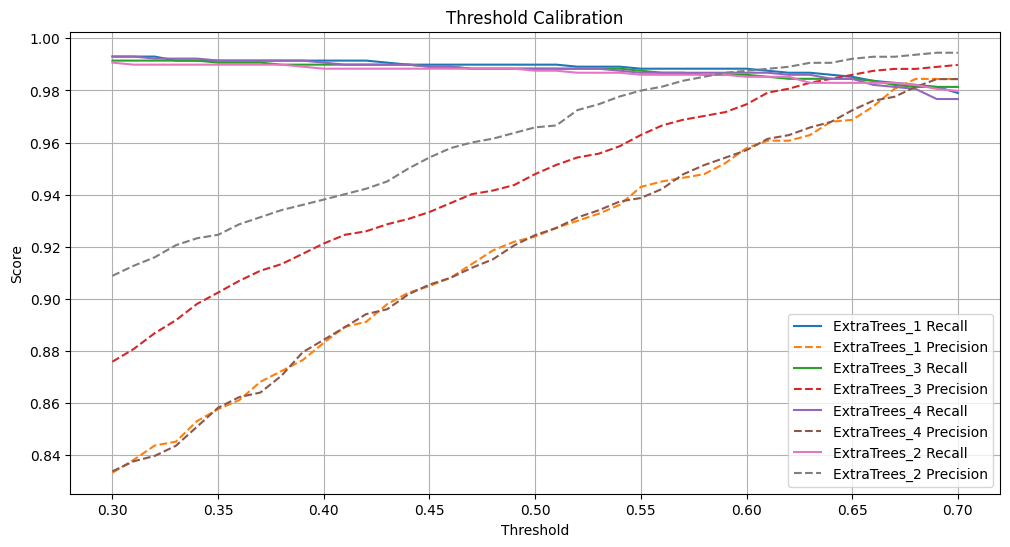

In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score
)

# =========================================================
# THRESHOLD RANGE
# =========================================================

thresholds = np.arange(0.30, 0.71, 0.01)

# =========================================================
# 10 FOLD CV
# =========================================================

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# =========================================================
# THRESHOLD CALIBRATION
# =========================================================

print("="*70)
print("RUNNING THRESHOLD CALIBRATION")
print("="*70)

final_results = []

overall_start = time.time()

for model_name, model in tqdm(
    models.items(),
    desc="Evaluating Models"
):

    print("\n" + "-"*70)
    print(f"Generating Probabilities : {model_name}")
    print("-"*70)

    start_time = time.time()

    # -----------------------------------------------------
    # CV PROBABILITIES
    # -----------------------------------------------------

    y_probs = cross_val_predict(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        method="predict_proba",

        n_jobs=-1

    )[:, 1]

    # -----------------------------------------------------
    # THRESHOLD SEARCH
    # -----------------------------------------------------

    best_row = None

    for threshold in thresholds:

        y_pred = (
            y_probs >= threshold
        ).astype(int)

        recall = recall_score(
            y_resampled,
            y_pred
        )

        precision = precision_score(
            y_resampled,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_resampled,
            y_pred
        )

        # -------------------------------------------------
        # KEEP ONLY GOOD THRESHOLDS
        # -------------------------------------------------

        if (
            recall >= 0.98 and
            precision >= 0.90
        ):

            if (
                best_row is None or
                precision > best_row["Precision"]
            ):

                best_row = {

                    "Model":
                        model_name,

                    "Threshold":
                        round(threshold, 2),

                    "Recall":
                        round(recall, 6),

                    "Precision":
                        round(precision, 6),

                    "F1 Score":
                        round(f1, 6),

                    "Params":
                        model.get_params()
                }

    end_time = time.time()

    # -----------------------------------------------------
    # SAVE BEST THRESHOLD
    # -----------------------------------------------------

    if best_row is not None:

        best_row["Time Taken"] = round(
            end_time-start_time,
            2
        )

        final_results.append(best_row)

        print(
            f"\nBest Threshold : "
            f"{best_row['Threshold']}"
        )

        print(
            f"Recall    : "
            f"{best_row['Recall']}"
        )

        print(
            f"Precision : "
            f"{best_row['Precision']}"
        )

    else:

        print(
            "\nNo good threshold found."
        )

    print(
        f"\nCompleted in "
        f"{(end_time-start_time):.2f} sec"
    )

overall_end = time.time()

# =========================================================
# FINAL RESULTS
# =========================================================

threshold_results_df = (

    pd.DataFrame(final_results)

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "F1 Score"
        ],

        ascending=False
    )
)

print("\n" + "="*70)
print("FINAL THRESHOLD RESULTS")
print("="*70)

print(
    f"\nTotal Experiment Time : "
    f"{(overall_end-overall_start)/60:.2f} min"
)

display(

    threshold_results_df[[
        "Model",
        "Threshold",
        "Recall",
        "Precision",
        "F1 Score",
        "Time Taken",
        "Params"
    ]]
)

# =========================================================
# OPTIONAL PLOTS
# =========================================================

plt.figure(figsize=(12, 6))

for model_name, model in models.items():

    y_probs = cross_val_predict(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        method="predict_proba",

        n_jobs=-1

    )[:, 1]

    recalls = []
    precisions = []

    for threshold in thresholds:

        y_pred = (
            y_probs >= threshold
        ).astype(int)

        recalls.append(
            recall_score(y_resampled, y_pred)
        )

        precisions.append(
            precision_score(
                y_resampled,
                y_pred,
                zero_division=0
            )
        )

    plt.plot(
        thresholds,
        recalls,
        label=f"{model_name} Recall"
    )

    plt.plot(
        thresholds,
        precisions,
        linestyle="--",
        label=f"{model_name} Precision"
    )

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Calibration")

plt.grid(True)
plt.legend()

plt.show()

RUNNING THRESHOLD CALIBRATION


Evaluating Models:   0%|          | 0/4 [00:00<?, ?it/s]


----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_1
----------------------------------------------------------------------

Best Threshold : 0.51
Recall    : 0.989907
Precision : 0.927273

Completed in 20.41 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_3
----------------------------------------------------------------------

Best Threshold : 0.37
Recall    : 0.990683
Precision : 0.910778

Completed in 18.53 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_4
----------------------------------------------------------------------

Best Threshold : 0.44
Recall    : 0.989907
Precision : 0.901697

Completed in 11.59 sec

----------------------------------------------------------------------
Generating Probabilities : ExtraTrees_2
----------------------------------------------------------------------



,Model,Threshold,Recall,Precision,F1 Score,Time Taken,Params
1,ExtraTrees_3,0.37,0.990683,0.910778,0.949052,18.53,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
3,ExtraTrees_2,0.30,0.990683,0.908832,0.947994,15.45,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
0,ExtraTrees_1,0.51,0.989907,0.927273,0.957567,20.41,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."
2,ExtraTrees_4,0.44,0.989907,0.901697,0.943745,11.59,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_..."


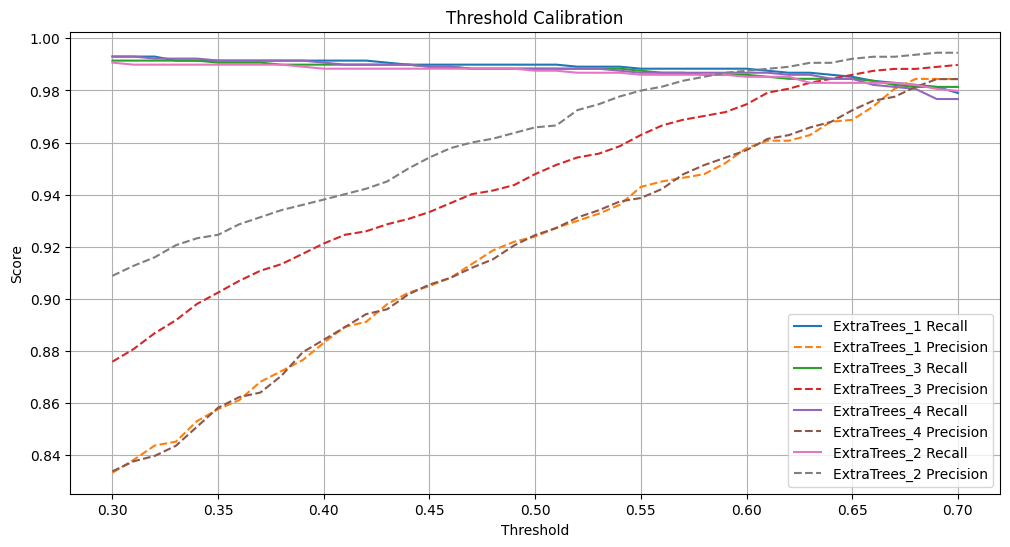

In [ ]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict
)

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score
)

# =========================================================
# THRESHOLD RANGE
# =========================================================

thresholds = np.arange(0.30, 0.71, 0.01)

# =========================================================
# 10 FOLD CV
# =========================================================

skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# =========================================================
# THRESHOLD CALIBRATION
# =========================================================

print("="*70)
print("RUNNING THRESHOLD CALIBRATION")
print("="*70)

final_results = []

overall_start = time.time()

for model_name, model in tqdm(
    models.items(),
    desc="Evaluating Models"
):

    print("\n" + "-"*70)
    print(f"Generating Probabilities : {model_name}")
    print("-"*70)

    start_time = time.time()

    # -----------------------------------------------------
    # CV PROBABILITIES
    # -----------------------------------------------------

    y_probs = cross_val_predict(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        method="predict_proba",

        n_jobs=-1

    )[:, 1]

    # -----------------------------------------------------
    # THRESHOLD SEARCH
    # -----------------------------------------------------

    best_row = None

    for threshold in thresholds:

        y_pred = (
            y_probs >= threshold
        ).astype(int)

        recall = recall_score(
            y_resampled,
            y_pred
        )

        precision = precision_score(
            y_resampled,
            y_pred,
            zero_division=0
        )

        f1 = f1_score(
            y_resampled,
            y_pred
        )

        # -------------------------------------------------
        # FILTER GOOD ZONE
        # -------------------------------------------------

        if (
            recall >= 0.98 and
            precision >= 0.90
        ):

            current_row = {

                "Model":
                    model_name,

                "Threshold":
                    round(threshold, 2),

                "Recall":
                    round(recall, 6),

                "Precision":
                    round(precision, 6),

                "F1 Score":
                    round(f1, 6),

                "Params":
                    model.get_params()
            }

            # =============================================
            # PRIORITIZE RECALL FIRST
            # =============================================

            if best_row is None:

                best_row = current_row

            else:

                # HIGHER RECALL ALWAYS WINS
                if (
                    current_row["Recall"] >
                    best_row["Recall"]
                ):

                    best_row = current_row

                # IF RECALL SAME
                # THEN HIGHER PRECISION WINS
                elif (

                    current_row["Recall"] ==
                    best_row["Recall"]

                    and

                    current_row["Precision"] >
                    best_row["Precision"]

                ):

                    best_row = current_row

    end_time = time.time()

    # -----------------------------------------------------
    # SAVE BEST THRESHOLD
    # -----------------------------------------------------

    if best_row is not None:

        best_row["Time Taken"] = round(
            end_time-start_time,
            2
        )

        final_results.append(best_row)

        print(
            f"\nBest Threshold : "
            f"{best_row['Threshold']}"
        )

        print(
            f"Recall    : "
            f"{best_row['Recall']}"
        )

        print(
            f"Precision : "
            f"{best_row['Precision']}"
        )

    else:

        print(
            "\nNo good threshold found."
        )

    print(
        f"\nCompleted in "
        f"{(end_time-start_time):.2f} sec"
    )

overall_end = time.time()

# =========================================================
# FINAL RESULTS
# =========================================================

threshold_results_df = (

    pd.DataFrame(final_results)

    .sort_values(

        by=[
            "Recall",
            "Precision",
            "F1 Score"
        ],

        ascending=False
    )
)

print("\n" + "="*70)
print("FINAL THRESHOLD RESULTS")
print("="*70)

print(
    f"\nTotal Experiment Time : "
    f"{(overall_end-overall_start)/60:.2f} min"
)

display(

    threshold_results_df[[
        "Model",
        "Threshold",
        "Recall",
        "Precision",
        "F1 Score",
        "Time Taken",
        "Params"
    ]]
)

# =========================================================
# PLOTS
# =========================================================

plt.figure(figsize=(12, 6))

for model_name, model in models.items():

    y_probs = cross_val_predict(

        estimator=model,

        X=X_resampled,

        y=y_resampled,

        cv=skf,

        method="predict_proba",

        n_jobs=-1

    )[:, 1]

    recalls = []
    precisions = []

    for threshold in thresholds:

        y_pred = (
            y_probs >= threshold
        ).astype(int)

        recalls.append(
            recall_score(y_resampled, y_pred)
        )

        precisions.append(
            precision_score(
                y_resampled,
                y_pred,
                zero_division=0
            )
        )

    plt.plot(
        thresholds,
        recalls,
        label=f"{model_name} Recall"
    )

    plt.plot(
        thresholds,
        precisions,
        linestyle="--",
        label=f"{model_name} Precision"
    )

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Calibration")

plt.grid(True)
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score
)

from sklearn.model_selection import cross_val_predict

models_to_test = {
    "ExtraTrees_2": models["ExtraTrees_2"],
    "ExtraTrees_3": models["ExtraTrees_3"]
}

threshold = 0.40

results = []

for model_name, model in models_to_test.items():

    y_probs = cross_val_predict(

        model,
        X_resampled,
        y_resampled,

        cv=10,

        method="predict_proba",

        n_jobs=-1

    )[:, 1]

    y_pred = (y_probs >= threshold).astype(int)

    results.append({

        "Model":
            model_name,

        "Threshold":
            threshold,

        "Recall":
            recall_score(
                y_resampled,
                y_pred
            ),

        "Precision":
            precision_score(
                y_resampled,
                y_pred
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_resampled,
                y_pred
            ),

        "F1 Score":
            f1_score(
                y_resampled,
                y_pred
            )
    })

display(
    pd.DataFrame(results)
    .sort_values(
        by=["Recall", "Precision"],
        ascending=False
    )
)

,Model,Threshold,Recall,Precision,Balanced Accuracy,F1 Score
1,ExtraTrees_3,0.4,0.989907,0.919913,0.951796,0.953628
0,ExtraTrees_2,0.4,0.989130,0.939528,0.962683,0.963691


ExtraTreesClassifier(max_depth=14, n_estimators=520, n_jobs=1, random_state=42)


In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    recall_score,
    precision_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix
)

from imblearn.over_sampling import KMeansSMOTE

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

print("="*70)
print("ORIGINAL DISTRIBUTION")
print("="*70)

print("\nTrain:")
print(y_train.value_counts())

print("\nTest:")
print(y_test.value_counts())

# =========================================================
# SMOTE ONLY ON TRAIN
# =========================================================

smote = KMeansSMOTE(

    random_state=42,

    cluster_balance_threshold=0.005,

    k_neighbors=2
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

print("\n" + "="*70)
print("AFTER KMEANS SMOTE")
print("="*70)

print(pd.Series(y_train_resampled).value_counts())

# =========================================================
# USE LOADED MODEL
# =========================================================

model = models["ExtraTrees_3"]

print("\n" + "="*70)
print("USING MODEL : ExtraTrees_3")
print("="*70)

# =========================================================
# TRAIN
# =========================================================

model.fit(
    X_train_resampled,
    y_train_resampled
)

# =========================================================
# THRESHOLD PREDICTION
# =========================================================

threshold = 0.40

print(f"\nUsing Threshold : {threshold}")

y_probs = model.predict_proba(X_test)[:, 1]

y_pred = (
    y_probs >= threshold
).astype(int)

# =========================================================
# METRICS
# =========================================================

results_df = pd.DataFrame({

    "Metric": [

        "Recall",
        "Precision",
        "F1 Score",
        "Balanced Accuracy",
        "ROC AUC"

    ],

    "Value": [

        recall_score(y_test, y_pred),

        precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),

        f1_score(y_test, y_pred),

        balanced_accuracy_score(
            y_test,
            y_pred
        ),

        roc_auc_score(
            y_test,
            y_probs
        )
    ]
})

print("\n" + "="*70)
print("FINAL HOLDOUT RESULTS")
print("="*70)

display(results_df)

# =========================================================
# CONFUSION MATRIX
# =========================================================

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred
).ravel()

cm_df = pd.DataFrame({

    "Value": [
        tn,
        fp,
        fn,
        tp
    ]

}, index=[

    "True Negative",
    "False Positive",
    "False Negative",
    "True Positive"
])

print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

display(cm_df)

ORIGINAL DISTRIBUTION

Train:
Y
0.0    1028
1.0      53
Name: count, dtype: int64

Test:
Y
0.0    258
1.0     13
Name: count, dtype: int64

AFTER KMEANS SMOTE
Y
1.0    1031
0.0    1028
Name: count, dtype: int64

USING MODEL : ExtraTrees_3

Using Threshold : 0.4

FINAL HOLDOUT RESULTS


,Metric,Value
0,Recall,0.384615
1,Precision,0.227273
2,F1 Score,0.285714
3,Balanced Accuracy,0.659362
4,ROC AUC,0.859571



CONFUSION MATRIX


,Value
True Negative,241
False Positive,17
False Negative,8
True Positive,5
